In [12]:
import librosa
from IPython.display import Audio
import numpy as np
import cv2
import matplotlib.pyplot as plt
import soundfile as sf
from pydub import AudioSegment
import sounddevice as sd

def get_optimal_font_scale(text, width):
    for scale in reversed(range(0, 60, 1)):
        textSize = cv2.getTextSize(text, fontFace=cv2.FONT_HERSHEY_DUPLEX, fontScale=scale/10, thickness=1)
        new_width = textSize[0][0]
        if (new_width <= width):
            return scale/10
    return 1

def put_multiline_text(img, lines, font, font_scale, color, thickness, start_y, line_spacing=20, center_x=True):
    for i, line in enumerate(lines):
        (text_width, text_height), _ = cv2.getTextSize(line, font, font_scale, thickness)
        text_x = (img.shape[1] - text_width) // 2 if center_x else 10
        text_y = start_y + i * (text_height + line_spacing)
        cv2.putText(img, line, (text_x, text_y), font, font_scale, color, thickness)
    return img

In [13]:
audio_file = "audio_files/AudioCleaner_Download_While My Guitar Gently Weeps (2018 Mix).mp3"
text = "Eu sou o Melhor!"

Execute o bloco a seguir se quiser gerar um áudio para codificar a frase

In [14]:
sr = 44100
canais = 1
arquivo_saida = "gravacao.wav"
audio_file = arquivo_saida

blocos = []

def callback(indata, frames, time, status):
    if status:
        print(status)
    blocos.append(indata.copy())

print("Gravando... pressione ENTER para parar.")

with sd.InputStream(samplerate=sr, channels=canais, dtype='float32', callback=callback):
    input()  # bloqueia até você apertar Enter

print("Gravação finalizada!")

audio = np.concatenate(blocos, axis=0)
sf.write(arquivo_saida, audio, sr)
print(f"Áudio salvo em: {arquivo_saida}")

Audio(audio.flatten(), rate=sr)

Gravando... pressione ENTER para parar.
Gravação finalizada!
Áudio salvo em: gravacao.wav


In [15]:
y, sr = librosa.load(
        audio_file,
        sr=None,
        mono=True
    )

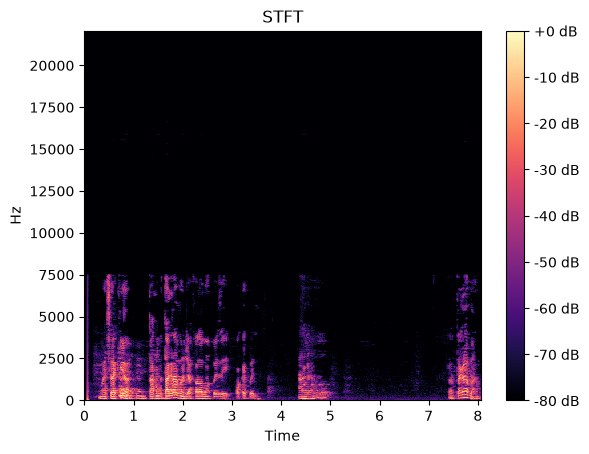

In [16]:
D_s = librosa.stft(y)
D_s_db = librosa.amplitude_to_db(np.abs(D_s), ref=np.max)

plt.figure()
librosa.display.specshow(D_s_db, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('STFT')
plt.show()

Sample rate: 44100
Duração: 8.062766439909296


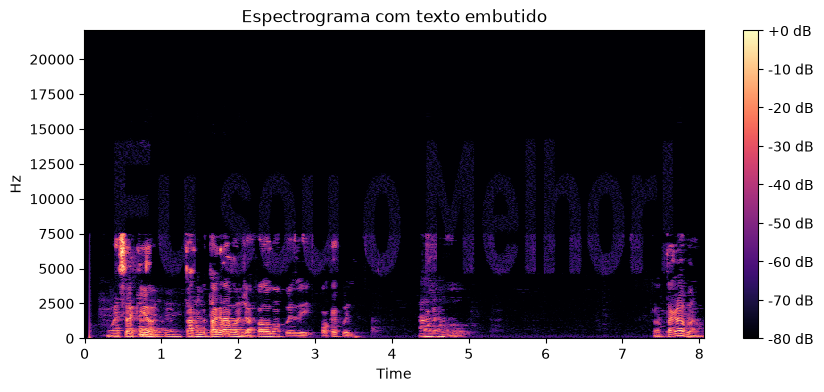

Áudio salvo em: audio_secreto.mp3


In [17]:
print("Sample rate:", sr)
print("Duração:", len(y) / sr)

D = librosa.stft(y)
magnitude, phase = np.abs(D), np.angle(D)
magnitude.shape

img_width = magnitude.shape[1]
img_height = magnitude.shape[0]

# --- Configurações do texto ---
lines = text.split("\n")

font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 2
color = 255
thickness = 2
line_spacing = 20  # espaço extra entre linhas, em pixels
pad = 20

line_sizes = [cv2.getTextSize(line, font, font_scale, thickness)[0] for line in lines]
max_text_width = max(w for w, h in line_sizes)
line_heights = [h for w, h in line_sizes]

total_text_height = sum(line_heights) + line_spacing * (len(lines) - 1)

canvas_w = max_text_width + pad * 2
canvas_h = total_text_height + pad * 2

# --- 2. Cria o canvas pequeno e desenha as linhas nele ---
img_small = np.zeros((canvas_h, canvas_w), dtype=np.uint8)

# start_y é a posição da linha de base da PRIMEIRA linha desenhada
start_y = pad + line_heights[0]
put_multiline_text(img_small, lines, font, font_scale, color, thickness, start_y, line_spacing)

# --- 3. Estica o canvas pequeno para o tamanho final do espectrograma ---
img_cv = cv2.resize(img_small, (img_width, img_height), interpolation=cv2.INTER_LINEAR)

# --- 4. Flip vertical (como no fluxo original) ---
img_cv = cv2.flip(img_cv, 0)

magnitude_mod = magnitude * (0.95 + 0.05 * img_cv)

plt.figure(figsize=(10, 4))
librosa.display.specshow(librosa.amplitude_to_db(magnitude_mod, ref=np.max),
sr=sr, x_axis='time', y_axis='hz')
plt.title("Espectrograma com texto embutido")
plt.colorbar(format='%+2.0f dB')
plt.show()

audio_reconstructed = librosa.istft(magnitude_mod * np.exp(1j * phase))

# --- Normalizar para evitar clipping (opcional, mas recomendado) ---
audio_reconstructed = audio_reconstructed / np.max(np.abs(audio_reconstructed))

# --- 1. Salvar como WAV primeiro ---
wav_path = "audio_secreto.wav"
sf.write(wav_path, audio_reconstructed, sr)

# --- 2. Converter WAV para MP3 usando pydub ---
mp3_path = "audio_secreto.mp3"
sound = AudioSegment.from_wav(wav_path)
sound.export(mp3_path, format="mp3")

print(f"Áudio salvo em: {mp3_path}")

Audio(audio_reconstructed, rate=sr)